# 📊 HR Employee Attrition Prediction

## Problem Statement
Employee attrition leads to increased hiring costs, reduced productivity, and loss of experienced talent. The goal of this project is to predict whether an employee will leave the company.

## Objective
To build a machine learning model that identifies employees at risk of attrition and helps organizations take proactive actions.

## 📦 Import Libraries

In [1]:
# importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE

## 📂 Load Dataset

In [2]:
# Load dataset

df = pd.read_csv('/content/HR-Employee-Attrition.csv')

df.head()

## 📈 Exploratory Data Analysis (EDA)

We explored feature distributions, relationships, and patterns to identify key factors influencing employee attrition.


In this section, we analyze the dataset to understand patterns, distributions, and relationships between features and attrition.

## 📊 EDA Summary

- Employees working overtime have significantly higher attrition  
- Low job satisfaction strongly increases attrition risk  
- Poor work-life balance is a major contributor to attrition  
- Lower income employees are more likely to leave  
- Employees with fewer years at company show higher attrition  

In [3]:
# Basic checks

print("Shape of the dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 rows:")
print(df.head())

Shape of the dataset: (1470, 35)

Columns:
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

Data Types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education              

In [4]:
print(df['Attrition'].value_counts())


Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [5]:
# Data Cleaning
# Check missing values
print("Missing values:\n")
print(df.isnull().sum())

# Check duplicates
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values:

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole     

In [6]:
# Drop Useless Columns

df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1, inplace=True)

In [7]:
# Data type Separation (Numerical features, categorical features)
# Feature Understanding

# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical columns:\n", num_cols)
print("\nCategorical columns:\n", cat_cols)


Numerical columns:
 Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

Categorical columns:
 Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')


In [8]:
# Data type Separation (Numerical features, categorical features)
# Feature Understanding

# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical columns:\n", num_cols)
print("\nCategorical columns:\n", cat_cols)


Numerical columns:
 Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

Categorical columns:
 Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')


In [9]:
# Remove target from categorical features
cat_cols = df.select_dtypes(include=['object']).columns.drop('Attrition')

print("Updated categorical columns:\n", cat_cols)

Updated categorical columns:
 Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


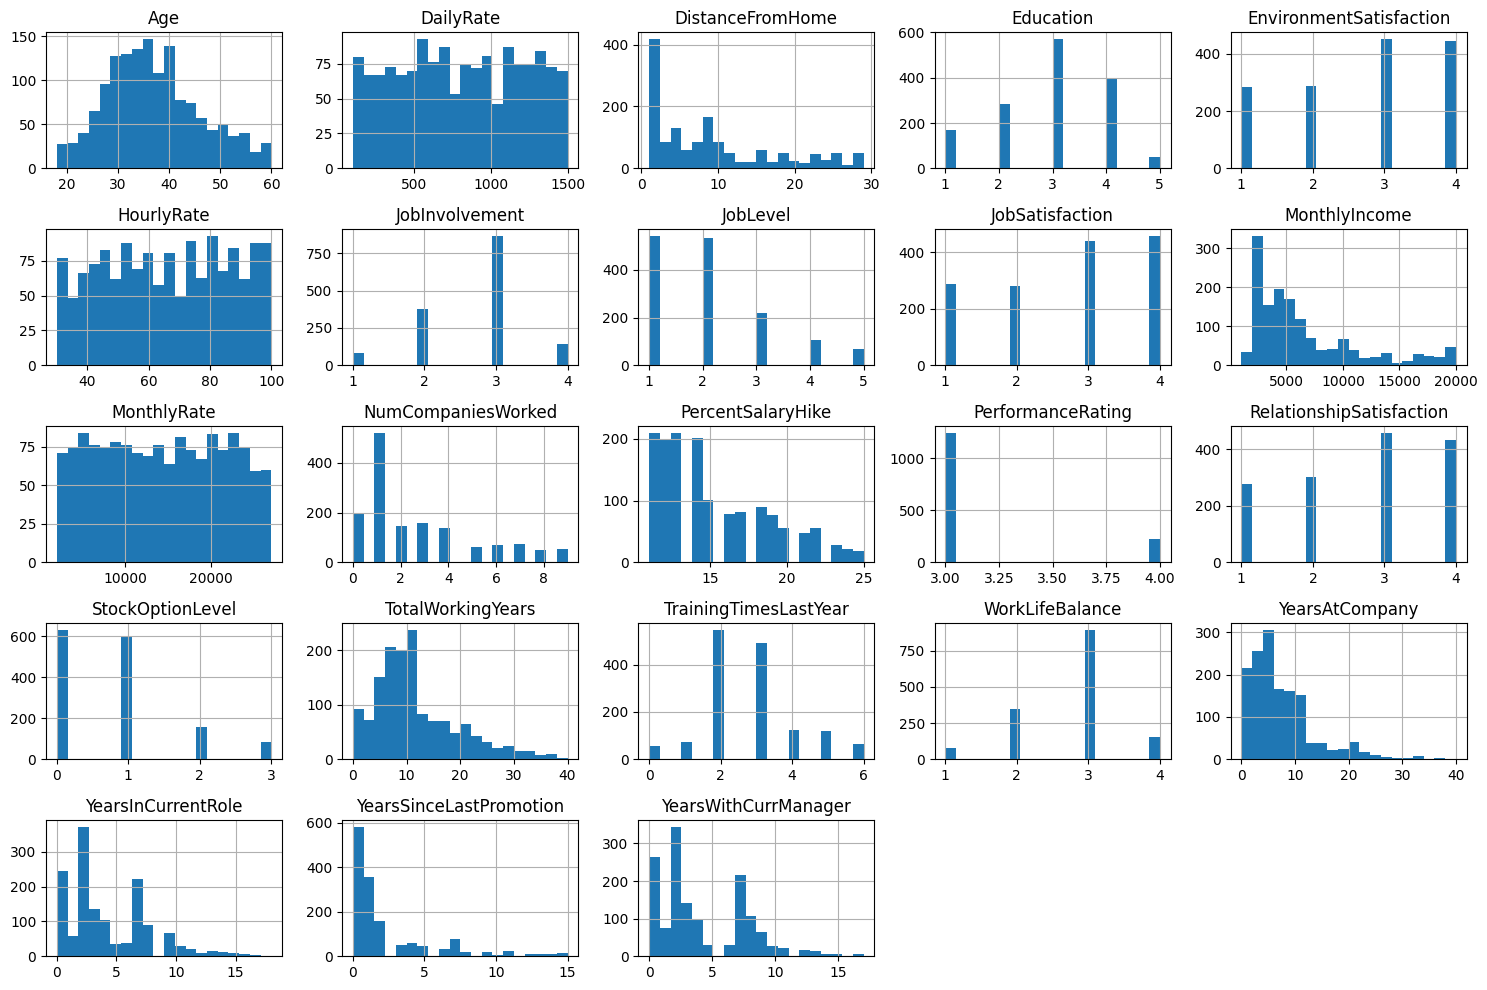

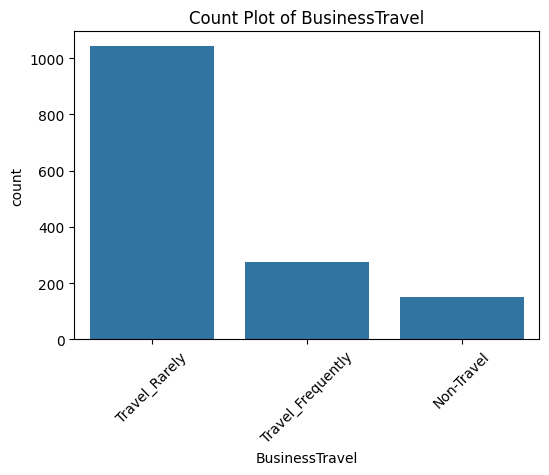

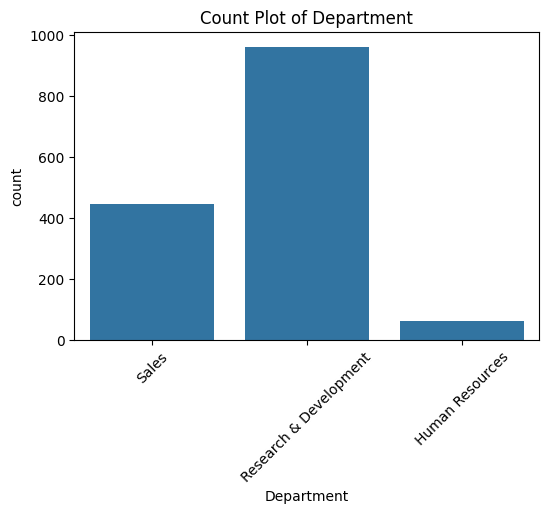

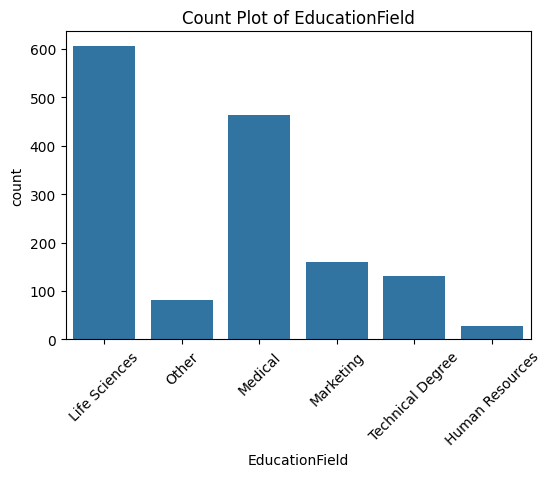

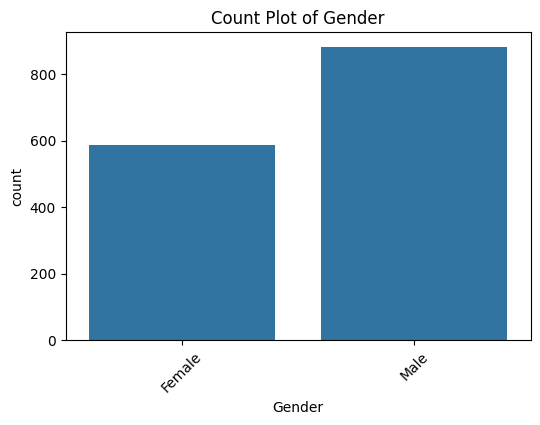

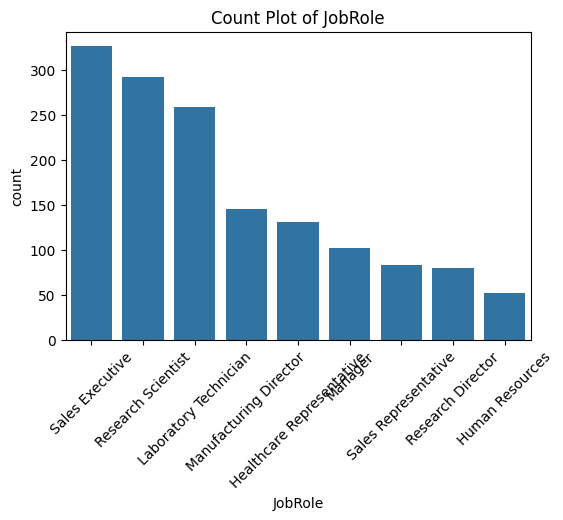

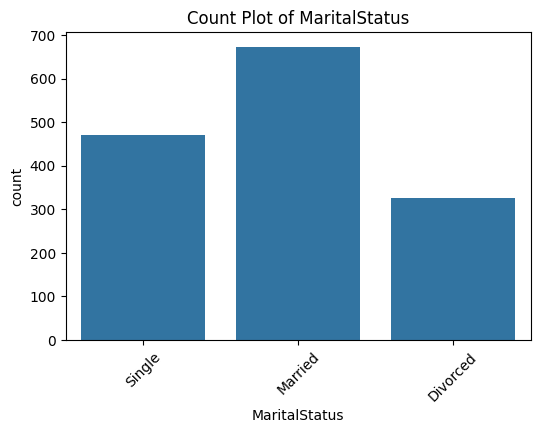

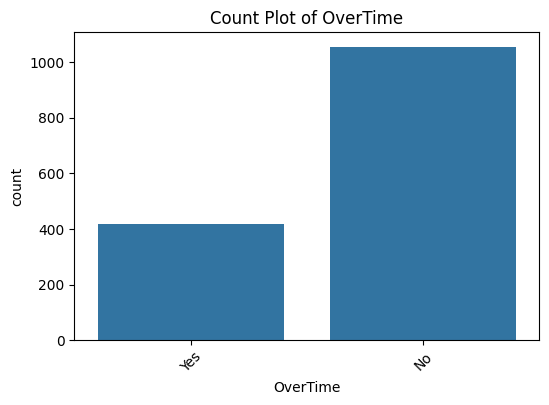

In [10]:
# Univariate Analysis (START OF EDA)

# Numerical Feature Distribution
# Plot histograms for numerical features
df[num_cols].hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()



# Categorical Feature Distribution
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

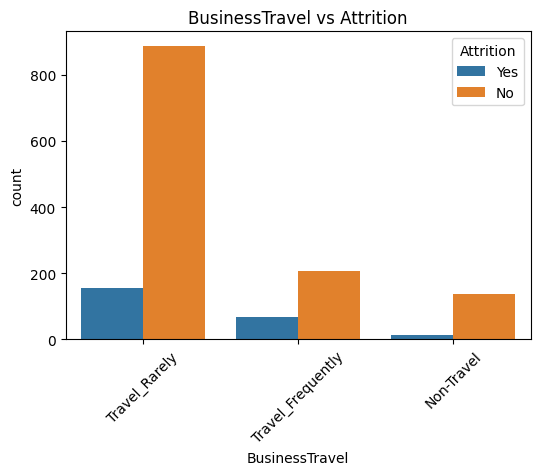

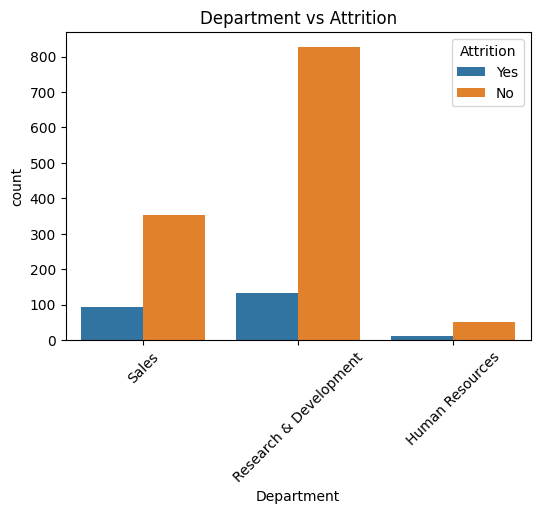

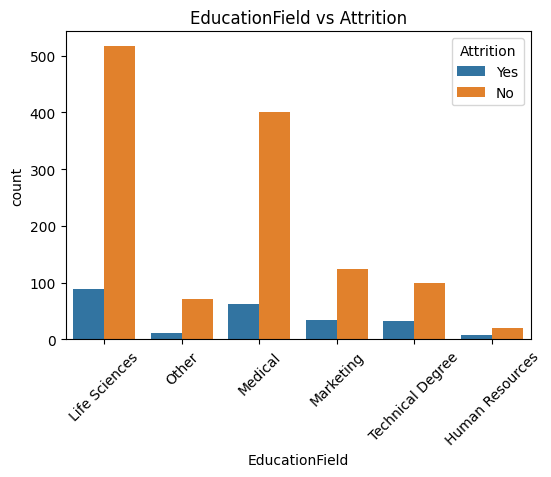

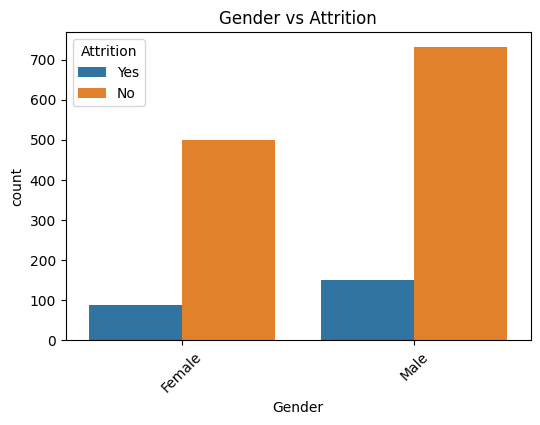

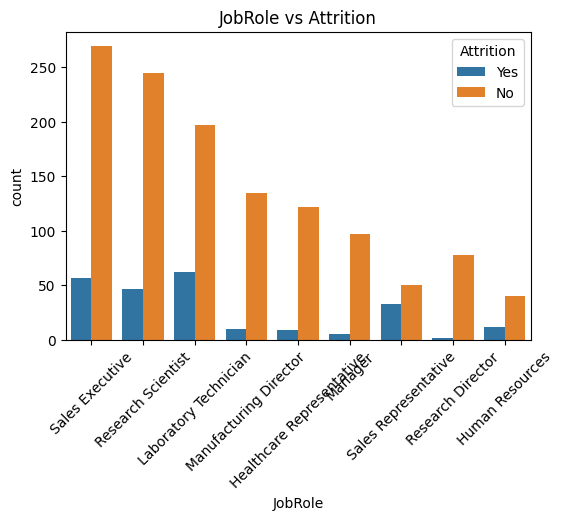

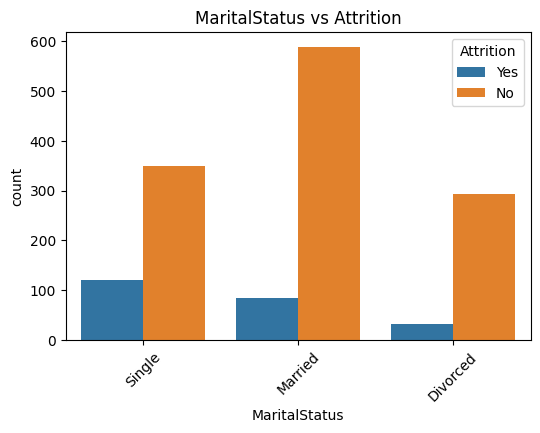

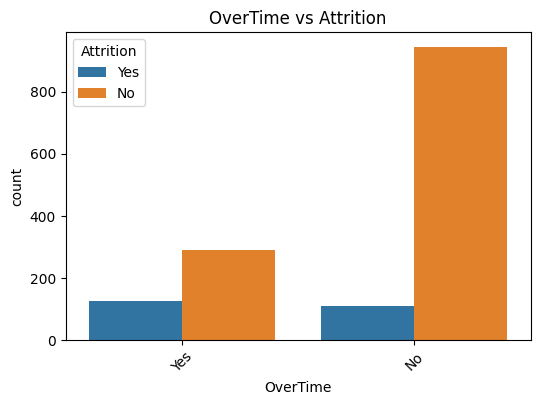

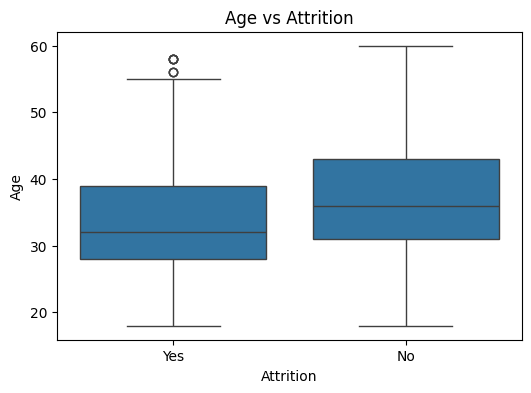

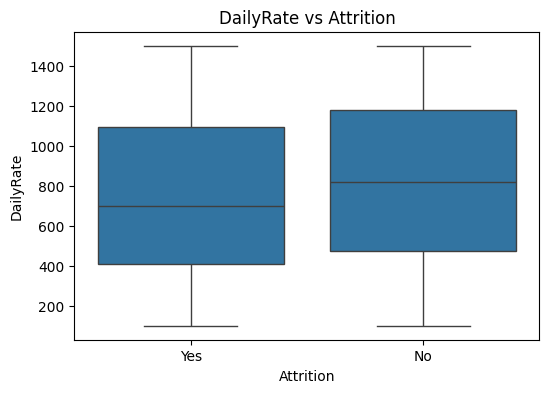

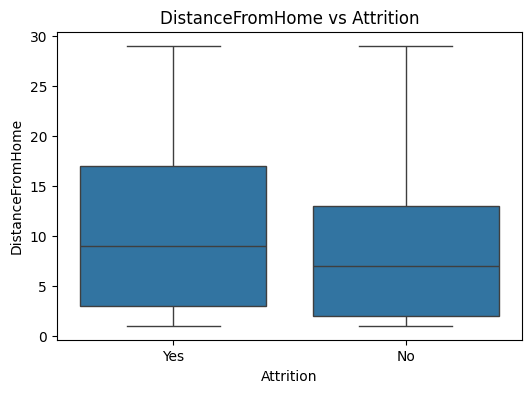

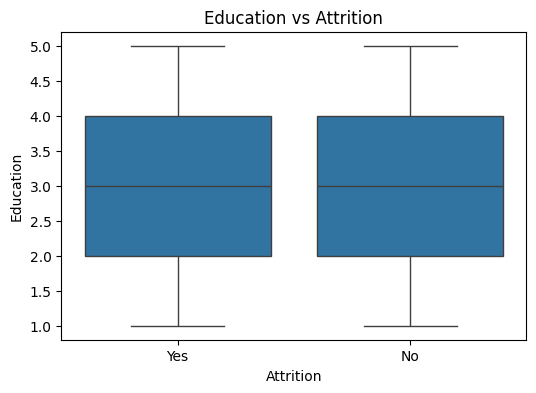

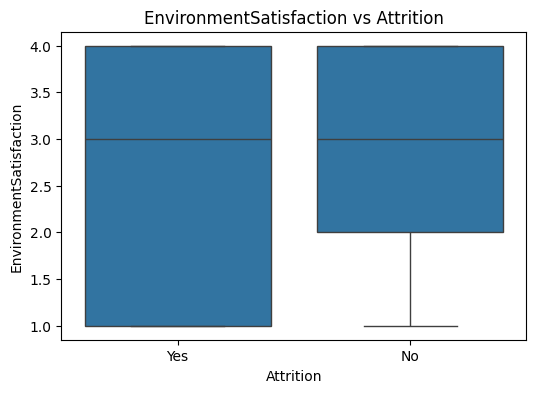

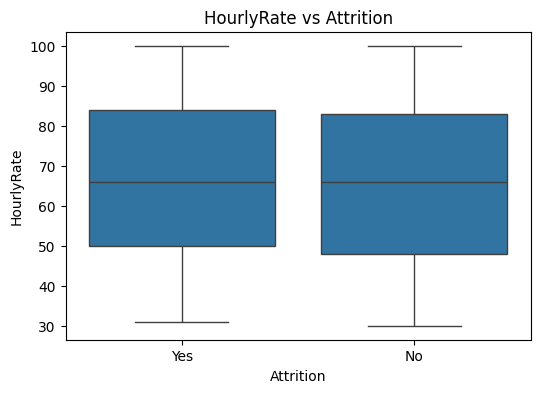

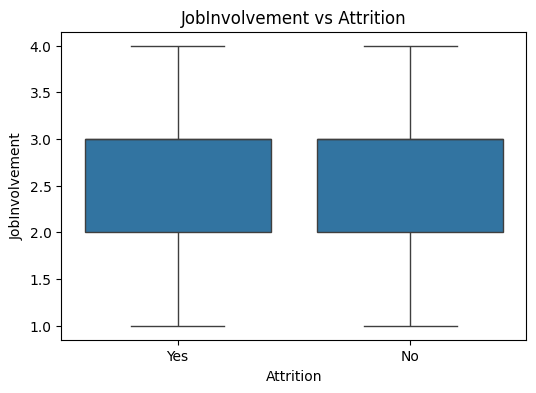

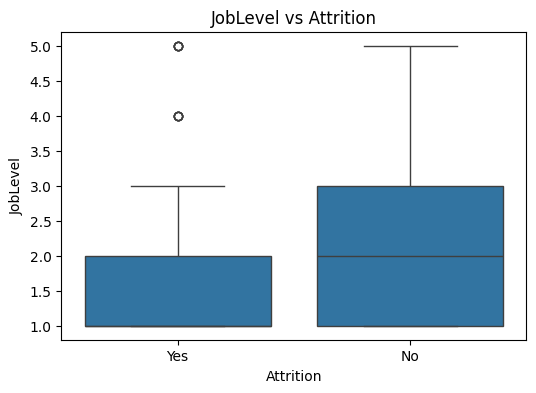

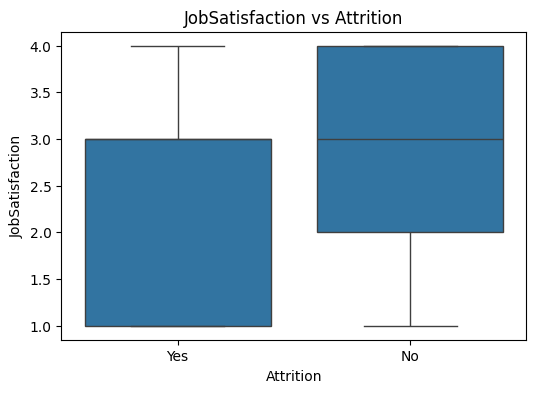

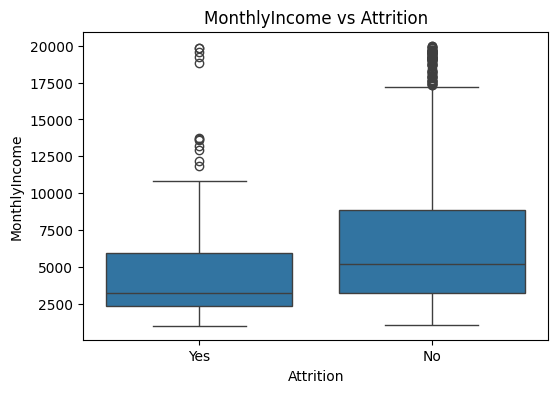

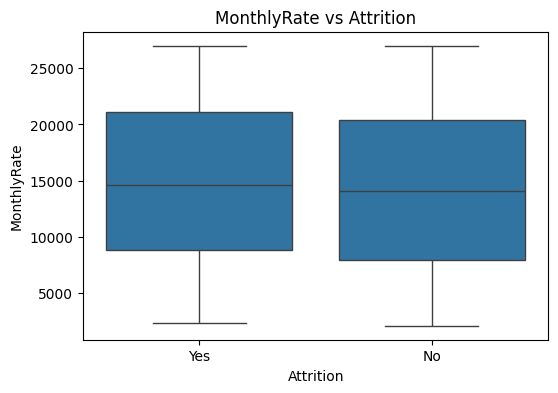

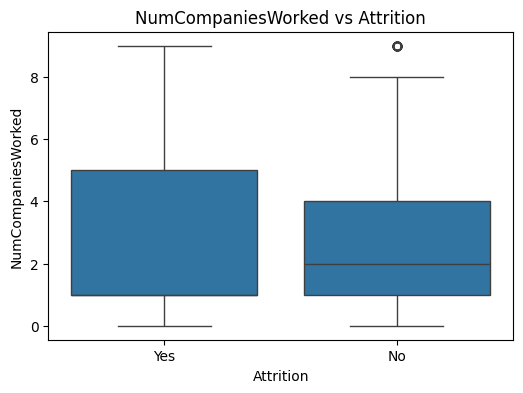

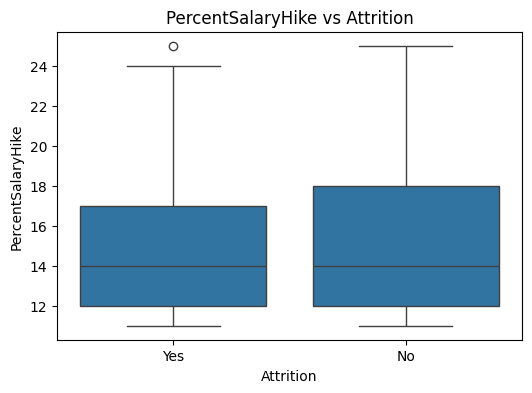

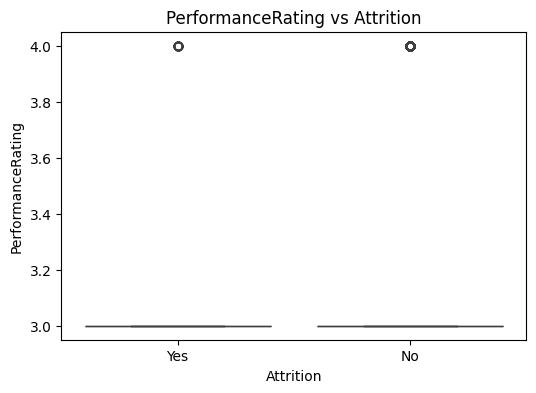

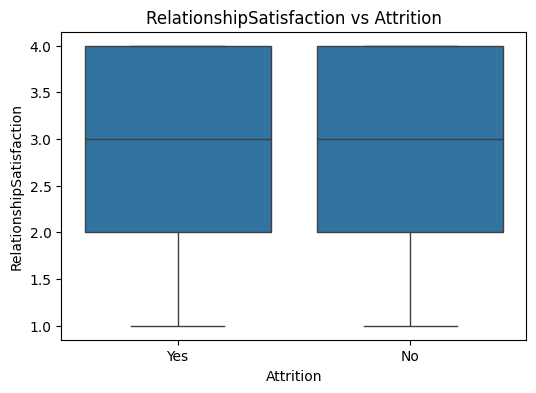

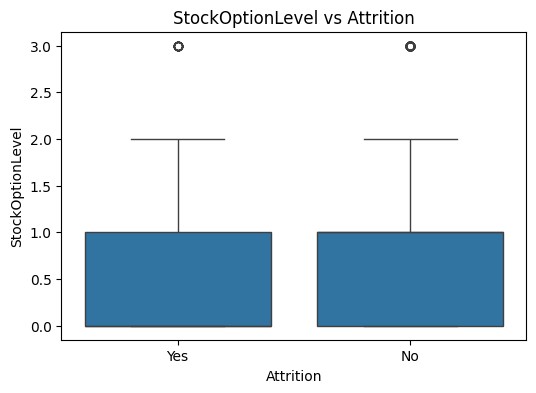

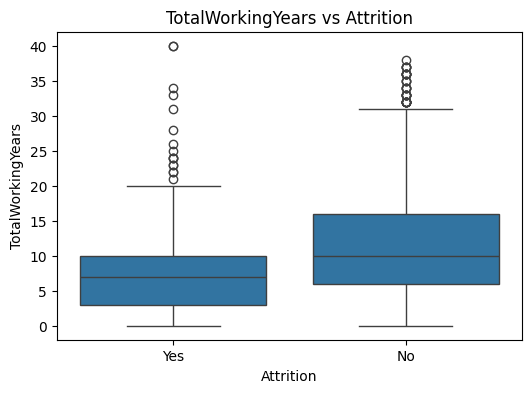

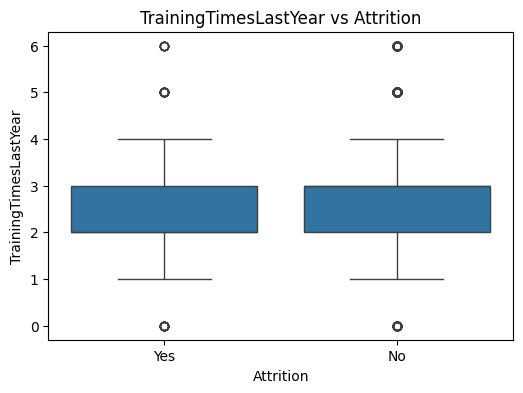

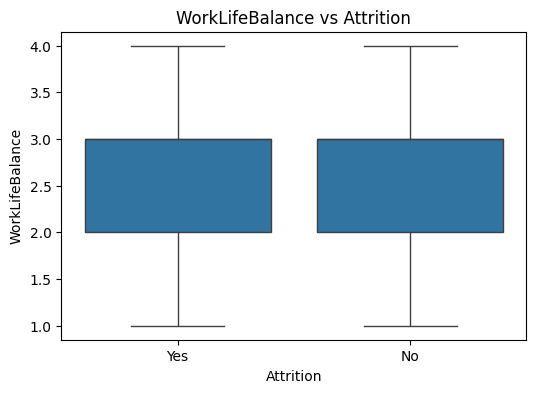

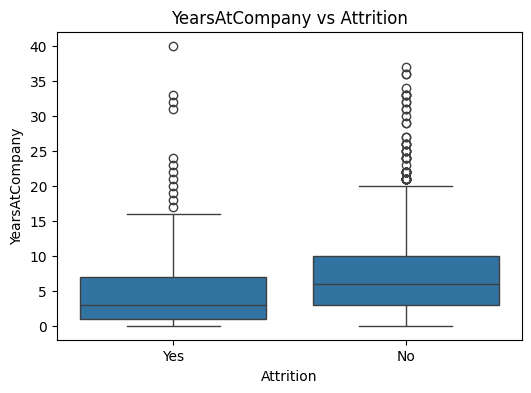

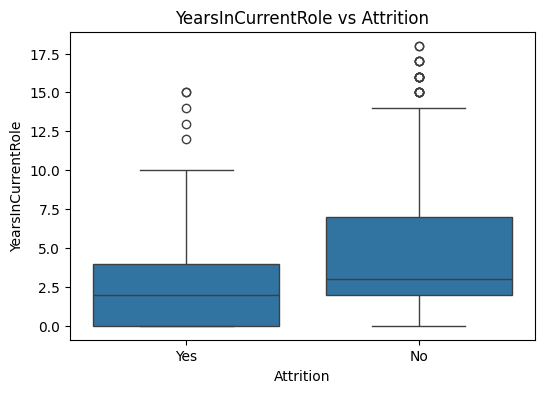

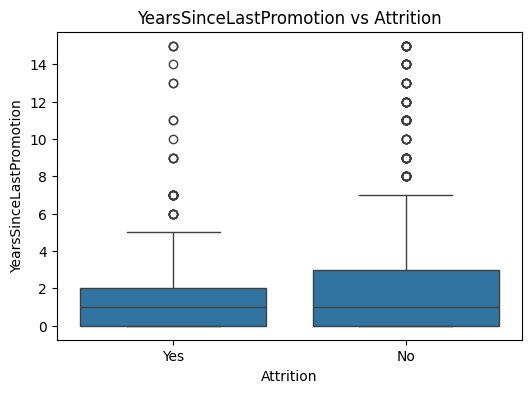

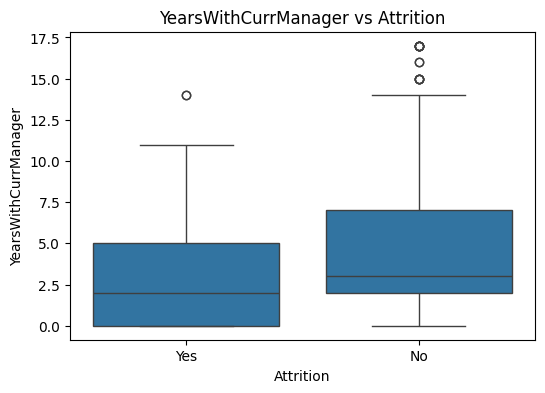

In [11]:
# Bivariate Analysis

# Attrition vs Categorical Features
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Attrition', data=df)
    plt.title(f"{col} vs Attrition")
    plt.xticks(rotation=45)
    plt.show()



# Attrition vs Numerical Features
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Attrition', y=col, data=df)
    plt.title(f"{col} vs Attrition")
    plt.show()




In [12]:
pd.crosstab(df['OverTime'], df['Attrition'], normalize='index')


Attrition,No,Yes
OverTime,,
No,0.895636,0.104364
Yes,0.694712,0.305288


In [13]:
print(pd.crosstab(df['JobSatisfaction'], df['Attrition'], normalize='index'))

Attrition              No       Yes
JobSatisfaction                    
1                0.771626  0.228374
2                0.835714  0.164286
3                0.834842  0.165158
4                0.886710  0.113290


In [14]:
print(pd.crosstab(df['WorkLifeBalance'], df['Attrition'], normalize='index'))

Attrition              No       Yes
WorkLifeBalance                    
1                0.687500  0.312500
2                0.831395  0.168605
3                0.857783  0.142217
4                0.823529  0.176471


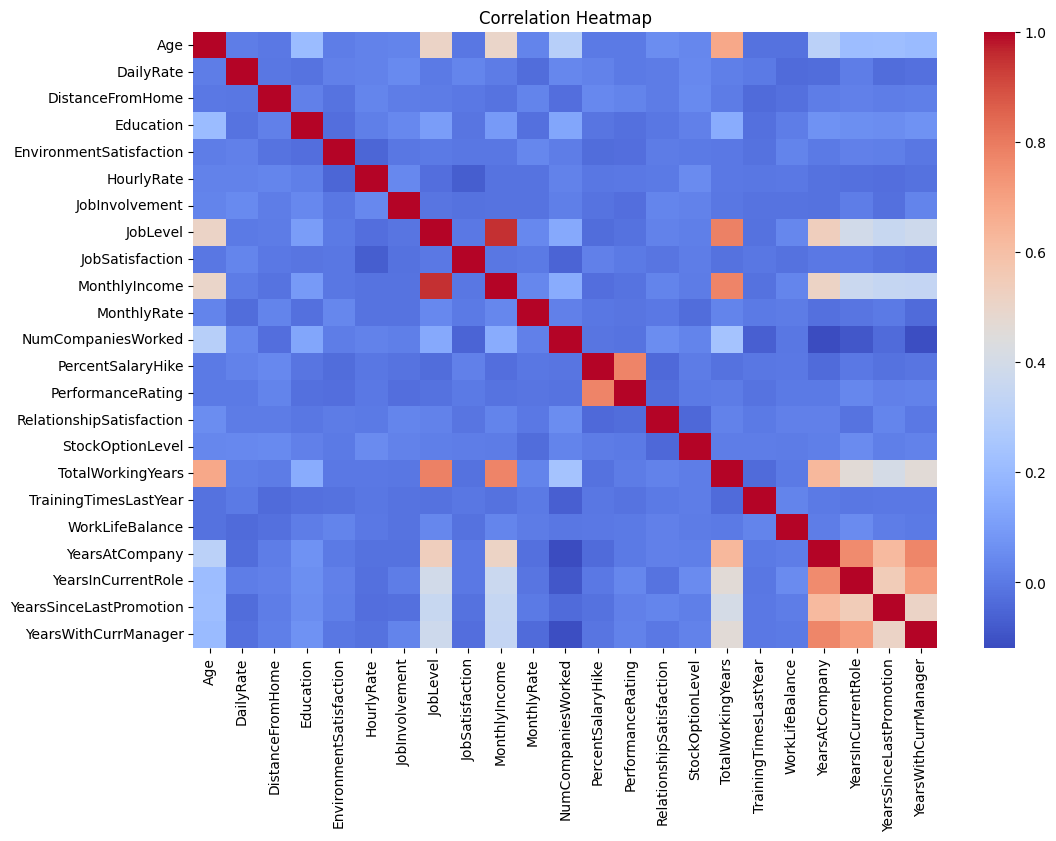

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

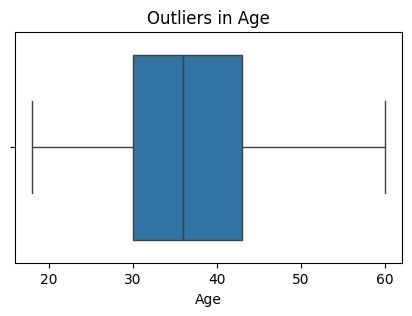

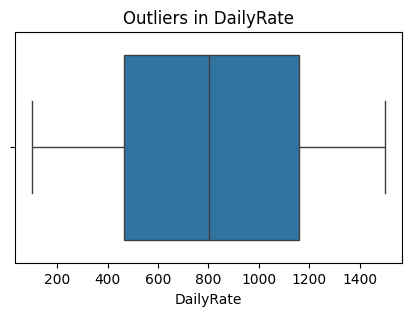

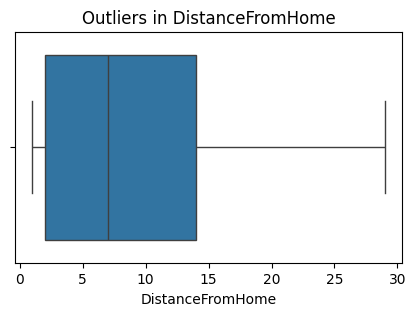

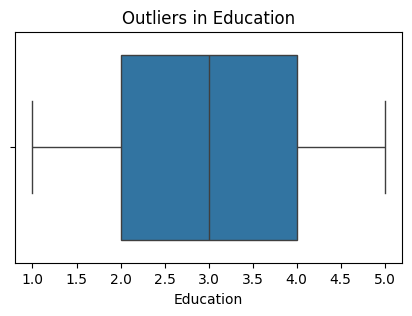

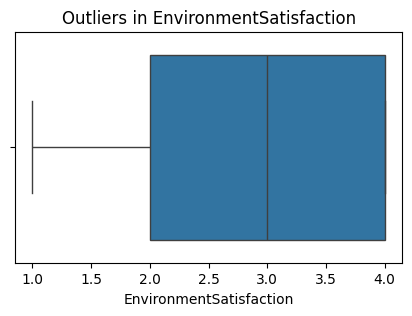

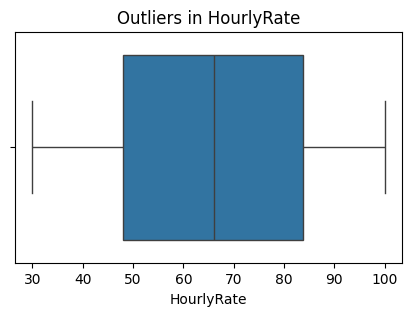

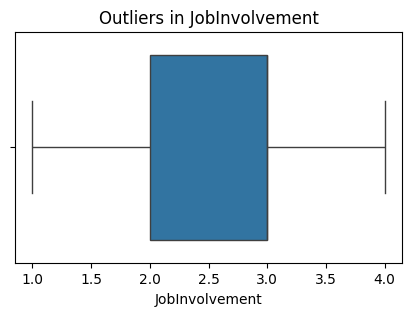

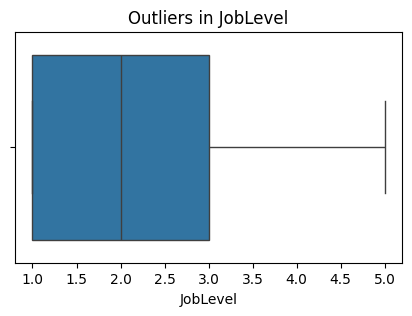

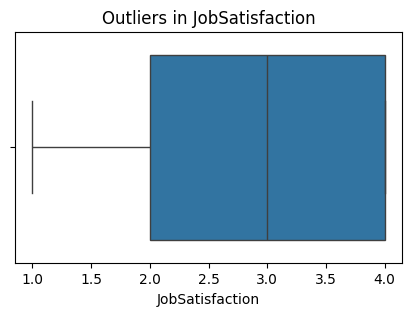

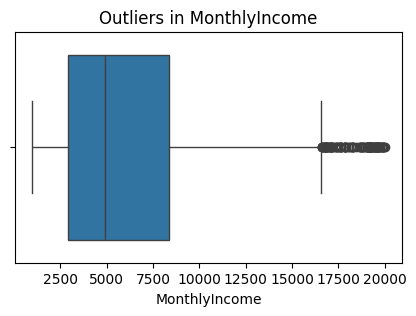

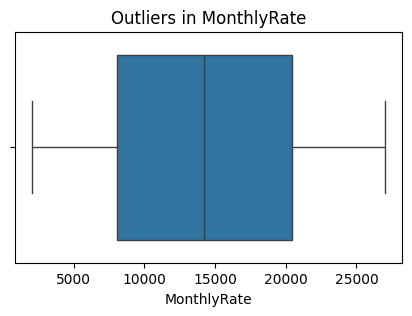

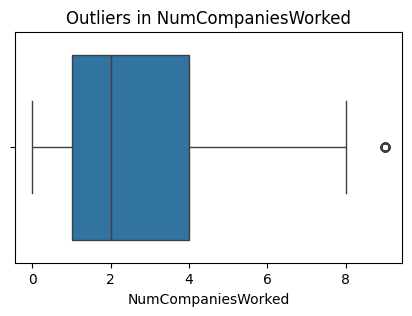

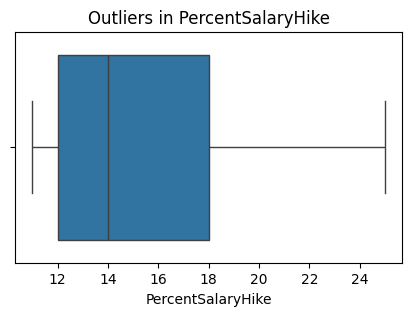

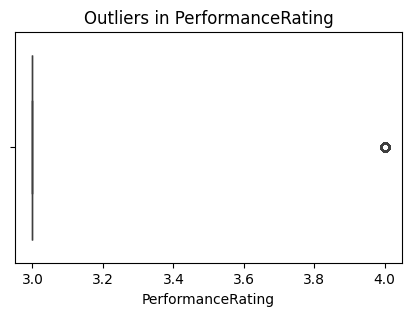

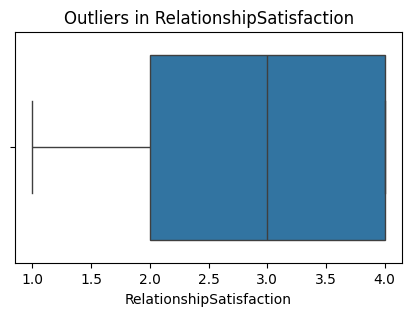

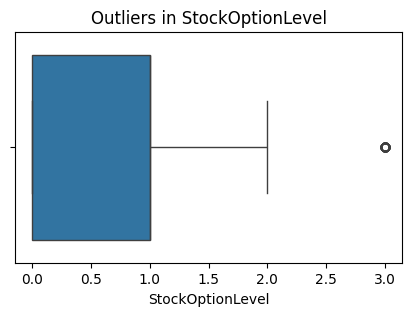

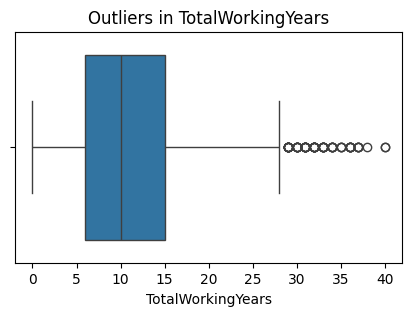

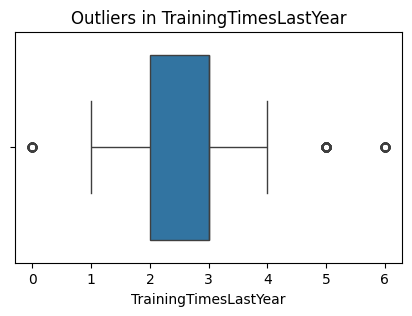

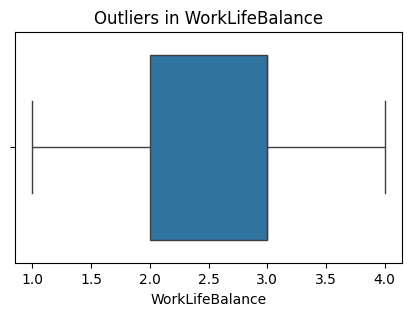

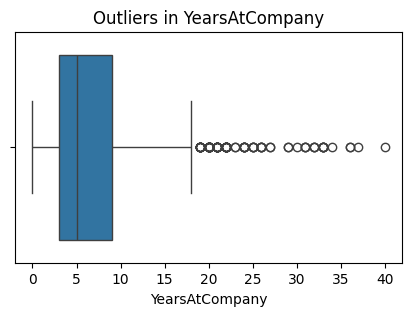

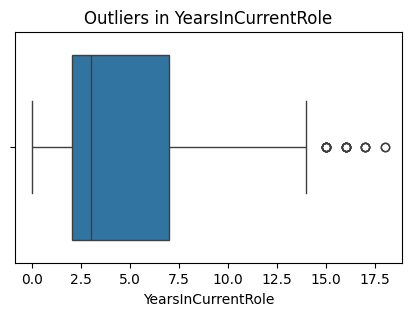

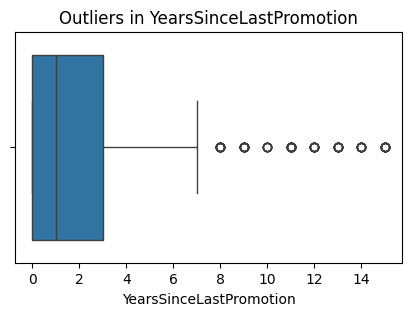

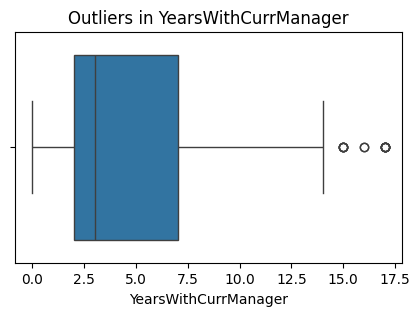

In [16]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

## ⚙️ Data Preprocessing

Steps performed:
- Removed unnecessary columns
- Encoded categorical variables
- Applied feature scaling
- Handled class imbalance using SMOTE


In [17]:
# Encoding

# Label encoding for binary columns

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode target
df['Attrition'] = le.fit_transform(df['Attrition'])

# Encode binary columns
df['Gender'] = le.fit_transform(df['Gender'])
df['OverTime'] = le.fit_transform(df['OverTime'])

In [18]:
# One-Hot Encoding (for multi-category columns)

df = pd.get_dummies(df, columns=[
    'BusinessTravel',
    'Department',
    'EducationField',
    'JobRole',
    'MaritalStatus'
], drop_first=True)

In [19]:
# veryfying encoding

df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,...,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,3,1,61,2,2,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,...,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,4,0,56,3,1,...,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,1,1,40,3,1,...,False,True,False,False,False,False,False,False,True,False


In [20]:
df.select_dtypes(include='object')

""
0
1
2
3
4
...
1465
1466
1467
1468


In [21]:
# Train-Test Split

from sklearn.model_selection import train_test_split

# Features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [22]:
# Apply scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train = scaler.fit_transform(X_train)

# Transform test data
X_test = scaler.transform(X_test)

In [23]:
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

In [24]:
# Apply SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [25]:
# No  = 1233   Yes = 237

# Bias model toward predicting “No”
# Reduce recall for “Yes” (important class)

# Applying SMOTE to create synthetic samples of minority class(attrition = yes)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [26]:
print(y_train.value_counts())
print(y_train_smote.value_counts())

Attrition
0    986
1    190
Name: count, dtype: int64
Attrition
0    986
1    986
Name: count, dtype: int64


## 🤖 Model Training

We trained multiple classification models:
- Logistic Regression
- Decision Tree
- Random Forest
- KNN
- XGBoost

Evaluation metrics:
- Accuracy
- Precision
- Recall
- F1 Score

In [27]:
# MODEL TRAINING

# 1 Logistic Regression

# Train model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_lr = lr.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.7755102040816326

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.81      0.86       247
           1       0.37      0.60      0.46        47

    accuracy                           0.78       294
   macro avg       0.64      0.70      0.66       294
weighted avg       0.83      0.78      0.79       294


Confusion Matrix:
 [[200  47]
 [ 19  28]]


In [28]:
#  2 Random Forest


rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.8435374149659864

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.95      0.91       247
           1       0.52      0.28      0.36        47

    accuracy                           0.84       294
   macro avg       0.70      0.61      0.64       294
weighted avg       0.82      0.84      0.82       294


Confusion Matrix:
 [[235  12]
 [ 34  13]]


In [29]:
# 3 KNN Model


knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_smote, y_train_smote)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

KNN Accuracy: 0.6224489795918368

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.64      0.74       247
           1       0.22      0.53      0.31        47

    accuracy                           0.62       294
   macro avg       0.55      0.59      0.53       294
weighted avg       0.77      0.62      0.67       294


Confusion Matrix:
 [[158  89]
 [ 22  25]]


In [30]:
# 4 Decision Tree


dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train_smote, y_train_smote)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7891156462585034

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.87      0.87       247
           1       0.35      0.36      0.35        47

    accuracy                           0.79       294
   macro avg       0.61      0.62      0.61       294
weighted avg       0.79      0.79      0.79       294


Confusion Matrix:
 [[215  32]
 [ 30  17]]


In [31]:
# 5 XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:08:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8741496598639455

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294



## 📊 Model Comparison Insights

- Logistic Regression achieved the highest recall (~68%), making it most effective for identifying employees likely to leave  
- Random Forest and XGBoost achieved higher accuracy but failed to detect many attrition cases  
- KNN and Decision Tree showed moderate performance but were less reliable  

| Model               | Accuracy | Recall (Attrition=1) | Verdict |
| ------------------- | -------- | -------------------- | ------- |
| Logistic Regression | ~56%     | **66%** ✅            | 🥇 BEST |
| KNN                 | ~61%     | 47%                  | 🥈      |
| Decision Tree       | ~76%     | 38%                  | 🥉      |
| Random Forest       | ~83%     | 30%                  | ❌       |
| XGBoost             | **85%**  | **26%** ❌            | ❌       |



## 🏆 Final Model Selection

Logistic Regression was selected as the best model after hyperparameter tuning.

- Recall: ~68%
- Accuracy: ~74%

This model performs best in identifying employees likely to leave, which is critical for business decision-making.



In [32]:
# Hyperparameter Tuning


param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid,
    cv=5,
    scoring='recall'
)

grid.fit(X_train_smote, y_train_smote)

best_lr = grid.best_estimator_

y_pred_best = best_lr.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

Best Parameters: {'C': 0.01, 'solver': 'liblinear'}
Accuracy: 0.7448979591836735

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.76      0.83       247
           1       0.35      0.68      0.46        47

    accuracy                           0.74       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.74      0.77       294



- Accuracy: ~74%
- Recall: ~68%

## 💡 Key Insights

- Overtime significantly increases attrition
- Low job satisfaction leads to higher attrition
- Poor work-life balance is a major factor
- Lower income employees are more likely to leave
- Employees with shorter tenure show higher attrition

## 🎯 Business Impact

This model enables HR teams to proactively identify employees at risk of leaving. By acting on these predictions, companies can reduce turnover costs, improve employee satisfaction, and maintain workforce stability.

## 📌 Conclusion

Logistic Regression performed best in identifying employees likely to leave, making it the most suitable model for this problem. The model can help organizations take proactive steps to reduce attrition.

This project demonstrates how machine learning can be used to solve real-world HR problems by identifying employees at risk of attrition and enabling proactive decision-making.